<a href="https://colab.research.google.com/github/GenilsonQ/pos-ciencia-dados/blob/main/mvp-puc/sprint_machine_learning_analytics/MVP_ML_Soja_Algodao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP - Machine Learning & Analytics

**Tema:** Previsão da produtividade de soja e algodão para produção de biodiesel utilizando Machine Learning (ML)  
**Nome:** Genilson do Nascimento Carvalho Júnior  
**Matrícula:** 4052026000122  
**Data:** 23/06/2026  
**Fonte de dados:** Pesquisa Agrícola Municipal (PAM), IBGE/SIDRA - tabela 5457  
**Tipo de problema:** Regressão supervisionada com divisão temporal

> Este notebook consulta a API pública do IBGE como fonte principal, sem login, token ou chave de API. Para aumentar a reprodutibilidade, o repositório também inclui um CSV de backup com a base bruta utilizada, que é carregado automaticamente caso a API esteja temporariamente indisponível.


## Checklist do MVP

| Item | Situação neste notebook |
|---|---|
| Problema, objetivo e tipo de tarefa definidos | Atendido |
| Dados públicos carregados por URL | Atendido |
| EDA conectada à modelagem | Atendido |
| Divisão temporal e prevenção de vazamento | Atendido |
| Baseline e modelos candidatos | Atendido |
| Ajuste de hiperparâmetros | Atendido |
| Métricas, análise de erros e limitações | Atendido |
| Conclusão e próximos passos | Atendido |

# 1. Definição do problema

## 1.1 Contexto

Soja e algodão são culturas relevantes para discutir a diversificação de matérias-primas da cadeia brasileira de biodiesel. A disponibilidade e o desempenho agrícola de cada cultura influenciam decisões de planejamento produtivo e de abastecimento.

## 1.2 Objetivo

Construir e comparar modelos de **ML** capazes de prever a **produtividade de soja e algodão no ano seguinte** (kg/ha) para cada combinação de cultura e Unidade da Federação (UF), usando indicadores da safra atual obtidos na **PAM/IBGE**.


## 1.3 Tipo de problema

É um problema de **regressão supervisionada temporal**: a variável-alvo é numérica e corresponde ao rendimento médio da produção no ano posterior. A separação entre treino e teste respeita a ordem dos anos, evitando que informações futuras sejam usadas no treinamento.

## 1.4 Premissas, hipóteses e critérios de sucesso

- Os dados da **PAM/IBGE** representam adequadamente os indicadores agrícolas anuais por UF.
- Variáveis observadas em um ano podem ajudar a estimar a produtividade do ano seguinte.
- O modelo deve superar um baseline ingênuo que sempre prevê a média histórica do conjunto de treino.
- Métrica principal: **MAE** em kg/ha; métricas complementares: RMSE, R² e MAPE.
- Este MVP não prevê diretamente a viabilidade total do biodiesel: custos industriais, clima, logística e teor de óleo, a ideia é apresentar um recorte.

# 2. Ambiente, bibliotecas e reprodutibilidade

In [ ]:
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Python: 3.12.13
pandas: 2.2.2
numpy: 2.0.2


# 3. Seleção e carga dos dados

## 3.1 Fonte

Os dados vêm da tabela 5457 da **Pesquisa Agrícola Municipal (PAM)** do IBGE/SIDRA: “Área plantada ou destinada à colheita, área colhida, quantidade produzida, rendimento médio e valor da produção das lavouras temporárias e permanentes”.

- Fonte: https://sidra.ibge.gov.br/tabela/5457
- API pública: `https://servicodados.ibge.gov.br/api/v3/agregados/5457/...`
- Arquivo de backup: `dataset_ibge_soja_algodao.csv`
- Produtos: Soja (em grão), código 40124; e Algodão herbáceo (em caroço), código 40099.
- Recorte territorial: Unidades da Federação, com uma série por produto.
- Período solicitado: 2000 a 2024. A API retornará apenas os anos efetivamente publicados.

A fonte principal é oficial, pública, anual e reproduzível. O arquivo `.csv` foi incluído apenas como cópia de segurança para permitir a execução do notebook caso a API do IBGE esteja indisponível no momento da avaliação.


In [ ]:
ANOS = list(range(2000, 2025))
PERIODOS = "|".join(map(str, ANOS))
CSV_BACKUP = "https://raw.githubusercontent.com/GenilsonQ/pos-ciencia-dados/main/mvp-puc/sprint_machine_learning_analytics/dataset_ibge_soja_algodao.csv"

# Codigos da classificacao 782 (produto das lavouras) na PAM/IBGE.
PRODUTOS = {
    "Soja (em grao)": "40124",
    "Algodao herbaceo (em caroco)": "40099",
}
URL_TEMPLATE = (
    "https://servicodados.ibge.gov.br/api/v3/agregados/5457/"
    f"periodos/{PERIODOS}/variaveis/8331|216|214|112|215?"
    "localidades=N3[all]&classificacao=782[{codigo}]"
)

VARIAVEIS = {
    "Área plantada ou destinada à colheita": "area_plantada_ha",
    "Área colhida": "area_colhida_ha",
    "Quantidade produzida": "producao_t",
    "Rendimento médio da produção": "produtividade_kg_ha",
    "Valor da produção": "valor_producao_mil_reais",
}


def carregar_pam_produto(produto, codigo, timeout=60):
    """Consulta a PAM/IBGE e devolve uma linha por produto, UF e ano."""
    url = URL_TEMPLATE.format(codigo=codigo)
    response = requests.get(url, timeout=timeout)
    response.raise_for_status()
    partes = []
    for bloco in response.json():
        coluna = VARIAVEIS.get(bloco["variavel"])
        if coluna is None:
            continue
        for resultado in bloco["resultados"]:
            for serie in resultado["series"]:
                for ano, valor in serie["serie"].items():
                    partes.append({"Produto": produto, "UF": serie["localidade"]["nome"], "Ano": int(ano), coluna: valor})
    longo = pd.DataFrame(partes)
    df_produto = longo.pivot_table(index=["Produto", "UF", "Ano"], values=list(VARIAVEIS.values()), aggfunc="first").reset_index()
    for coluna in VARIAVEIS.values():
        df_produto[coluna] = pd.to_numeric(df_produto[coluna].replace("-", np.nan), errors="coerce")
    return df_produto


def carregar_pam_ibge():
    """Carrega todos os produtos diretamente da API pública do IBGE."""
    return pd.concat(
        [carregar_pam_produto(produto, codigo) for produto, codigo in PRODUTOS.items()],
        ignore_index=True,
    )


try:
    df_raw = carregar_pam_ibge()
    fonte_carregamento = "API pública do IBGE"
    print("Dados carregados pela API pública do IBGE.")
except Exception as erro:
    print("Não foi possível carregar os dados pela API do IBGE.")
    print("Erro:", erro)
    print(f"Carregando cópia local de backup: {CSV_BACKUP}")
    df_raw = pd.read_csv(CSV_BACKUP)
    fonte_carregamento = "CSV local de backup"

df_raw = df_raw.sort_values(["Produto", "UF", "Ano"]).reset_index(drop=True)
print("Fonte usada:", fonte_carregamento)
print("Produtos consultados:", ", ".join(PRODUTOS))
print("Formato bruto:", df_raw.shape)
display(df_raw.head())


Produtos consultados: Soja (em grao), Algodao herbaceo (em caroco)
Formato bruto: (1350, 8)


,Produto,UF,Ano,area_colhida_ha,area_plantada_ha,producao_t,produtividade_kg_ha,valor_producao_mil_reais
0,Algodao herbaceo (em caroco),Acre,2000,60.0,60.0,33.0,550.0,23.0
1,Algodao herbaceo (em caroco),Acre,2001,88.0,88.0,53.0,602.0,34.0
2,Algodao herbaceo (em caroco),Acre,2002,40.0,40.0,48.0,1200.0,48.0
3,Algodao herbaceo (em caroco),Acre,2003,NaN,NaN,NaN,NaN,NaN
4,Algodao herbaceo (em caroco),Acre,2004,48.0,48.0,110.0,2291.0,198.0


## 3.2 Visão geral do dataset
Como a consulta retorna todas as combinações de produto, UF e ano, algumas linhas podem ter valores ausentes quando não há produção registrada para aquela cultura naquele local e período.


In [ ]:
print("Formato do dataset:", df_raw.shape)
print("\nTipos de dados:")
display(df_raw.dtypes.to_frame("tipo"))

print("\nValores ausentes por coluna:")
display(df_raw.isna().sum().to_frame("ausentes"))

print("\nDuplicatas considerando Produto + UF + Ano:", df_raw.duplicated(["Produto", "UF", "Ano"]).sum())

print("\nAmostra aleatória de registros:")
display(df_raw.sample(5, random_state=SEED))

Formato do dataset: (1350, 8)

Tipos de dados:


,tipo
Produto,object
UF,object
Ano,int64
area_colhida_ha,float64
area_plantada_ha,float64
producao_t,float64
produtividade_kg_ha,float64
valor_producao_mil_reais,float64



Valores ausentes por coluna:


,ausentes
Produto,0
UF,0
Ano,0
area_colhida_ha,451
area_plantada_ha,448
producao_t,451
produtividade_kg_ha,451
valor_producao_mil_reais,451



Duplicatas considerando Produto + UF + Ano: 0

Amostra aleatória de registros:


,Produto,UF,Ano,area_colhida_ha,area_plantada_ha,producao_t,produtividade_kg_ha,valor_producao_mil_reais
289,Algodao herbaceo (em caroco),Mato Grosso do Sul,2014,37707.0,37707.0,165061.0,4377.0,264540.0
1036,Soja (em grao),Paraíba,2011,NaN,NaN,NaN,NaN,NaN
535,Algodao herbaceo (em caroco),Rondônia,2010,NaN,NaN,NaN,NaN,NaN
346,Algodao herbaceo (em caroco),Paraná,2021,97.0,97.0,231.0,2381.0,438.0
1075,Soja (em grao),Pernambuco,2000,NaN,NaN,NaN,NaN,NaN


## 3.3 Dicionário de dados

| Coluna | Tipo | Descrição | Uso no modelo |
|---|---|---|---|
| Produto | categórica | Soja ou algodão herbáceo | Feature |
| UF | categórica | Unidade da Federação | Feature |
| Ano | numérica | Ano da safra | Feature |
| area_plantada_ha | numérica | Área plantada/destinada à colheita | Feature da safra atual |
| area_colhida_ha | numérica | Área efetivamente colhida | Feature da safra atual |
| producao_t | numérica | Quantidade produzida em toneladas | Feature da safra atual |
| produtividade_kg_ha | numérica | Rendimento médio da safra | Feature da safra atual |
| valor_producao_mil_reais | numérica | Valor da produção em mil reais correntes | Feature da safra atual |
| produtividade_proximo_ano_kg_ha | numérica | Rendimento da safra seguinte | **Alvo** |

# 4. Análise exploratória dos dados

In [ ]:
print("Período retornado:", df_raw["Ano"].min(), "a", df_raw["Ano"].max())
print("Número de UFs:", df_raw["UF"].nunique())
print("Duplicatas Produto + UF + Ano:", df_raw.duplicated(["Produto", "UF", "Ano"]).sum())
display(df_raw.info())
display(df_raw.describe(include="all").T)


Período retornado: 2000 a 2024
Número de UFs: 27
Duplicatas UF + Ano: 675
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Produto                   1350 non-null   object 
 1   UF                        1350 non-null   object 
 2   Ano                       1350 non-null   int64  
 3   area_colhida_ha           899 non-null    float64
 4   area_plantada_ha          902 non-null    float64
 5   producao_t                899 non-null    float64
 6   produtividade_kg_ha       899 non-null    float64
 7   valor_producao_mil_reais  899 non-null    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 84.5+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Produto,1350,2,Algodao herbaceo (em caroco),675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UF,1350,27,Acre,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ano,1350.0,NaN,NaN,NaN,2012.0,7.213775,2000.0,2006.0,2012.0,2018.0,2024.0
area_colhida_ha,899.0,NaN,NaN,NaN,812011.143493,1716175.870418,1.0,3676.0,48450.0,718026.5,12351963.0
area_plantada_ha,902.0,NaN,NaN,NaN,811506.707317,1718470.249254,2.0,3673.25,46782.0,716115.0,12383077.0
producao_t,899.0,NaN,NaN,NaN,2442194.299221,5366579.681428,1.0,6791.0,146940.0,2221082.5,44425783.0
produtividade_kg_ha,899.0,NaN,NaN,NaN,2734.083426,1025.447426,148.0,2331.0,2938.0,3406.0,5333.0
valor_producao_mil_reais,899.0,NaN,NaN,NaN,3134860.8198,8845843.850801,0.0,7239.0,177851.0,2015013.0,105106390.0


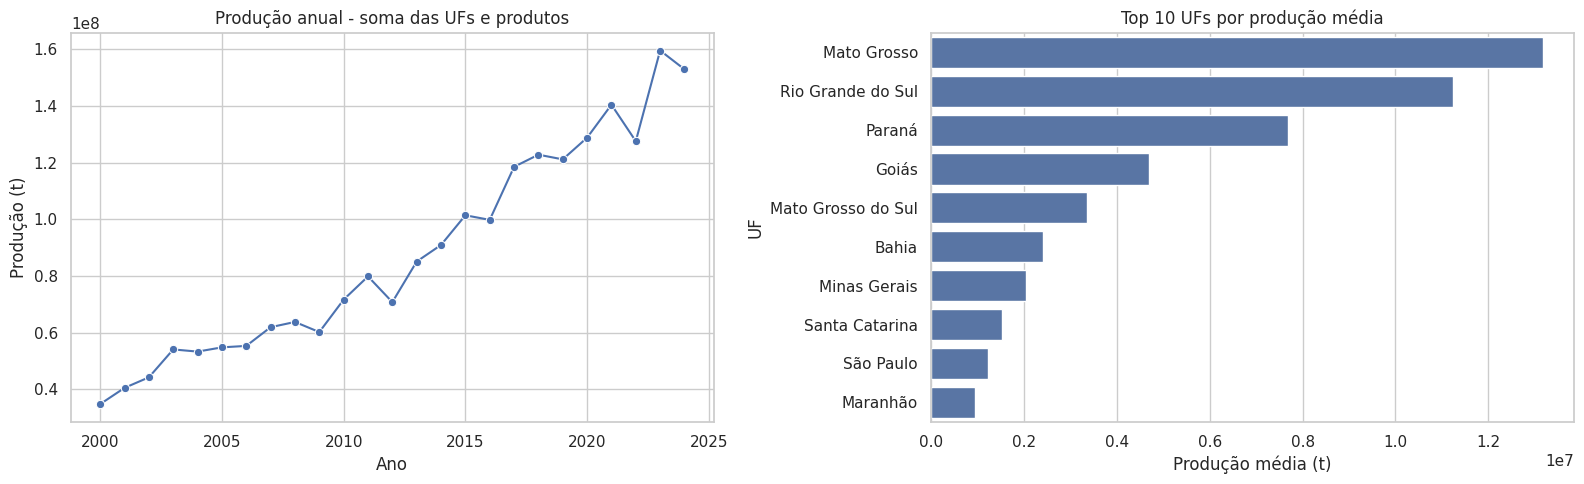

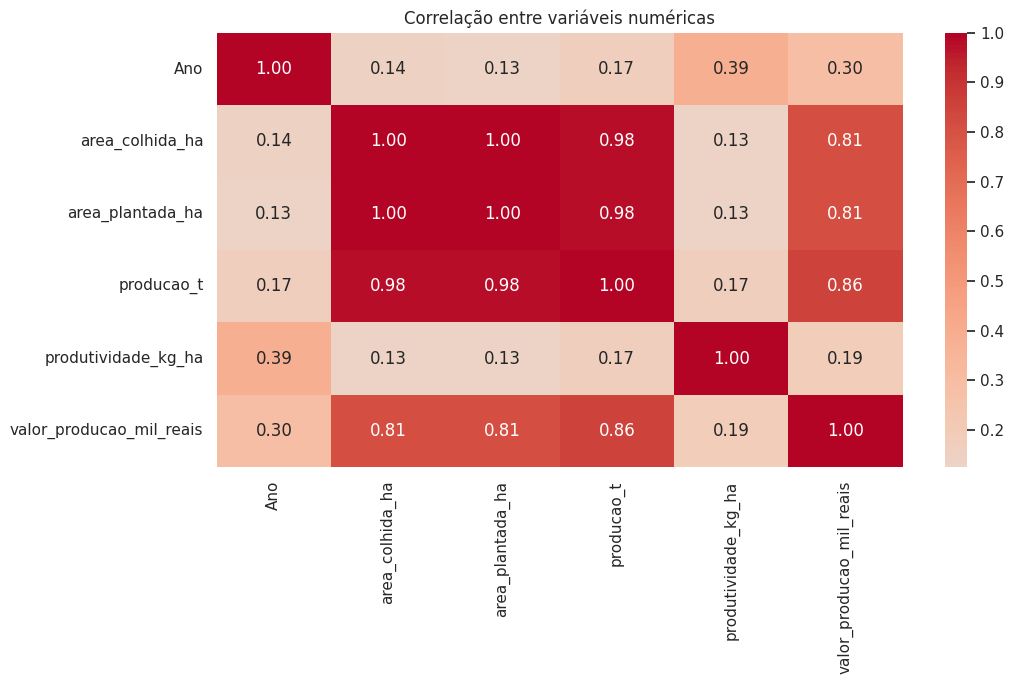

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

serie_brasil = df_raw.groupby("Ano", as_index=False).agg(
    producao_t=("producao_t", "sum"),
    area_plantada_ha=("area_plantada_ha", "sum")
)
sns.lineplot(data=serie_brasil, x="Ano", y="producao_t", marker="o", ax=axes[0])
axes[0].set_title("Produção anual - soma das UFs e produtos")
axes[0].set_ylabel("Produção (t)")

top_ufs = (df_raw.groupby("UF", as_index=False)["producao_t"].mean()
           .sort_values("producao_t", ascending=False).head(10))
sns.barplot(data=top_ufs, x="producao_t", y="UF", ax=axes[1])
axes[1].set_title("Top 10 UFs por produção média")
axes[1].set_xlabel("Produção média (t)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 7))
sns.heatmap(df_raw.select_dtypes("number").corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

## 4.1 Síntese da EDA

- Área plantada, área colhida e produção possuem correlação muito alta, pois culturas com maior área tendem a produzir mais. Já a produtividade apresenta relação mais fraca com essas variáveis, indicando que produzir mais não significa necessariamente produzir melhor por hectare.

- Existem valores ausentes em algumas combinações de produto, UF e ano, principalmente em situações sem produção registrada. Recomendação: utilizar imputação de valores ausentes dentro do pipeline de pré-processamento.

- As variáveis apresentam escalas muito diferentes (área, produção e valor da produção) têm magnitudes muito maiores que a produtividade. Recomendação: variáveis numéricas devem ser padronizadas no pipeline, especialmente para o modelo Ridge.

- A alta correlação entre área plantada, área colhida e produção sugere possível redundância entre atributos e relações que podem ser não lineares. Recomendação: realizar comparação envolvendo um modelo linear regularizado (Ridge) e modelos baseados em árvores (Random Forest e Extra Trees), capazes de capturar interações e relações não lineares.

# 5. Preparação dos dados e divisão temporal

O alvo é criado por uma junção explícita com a produtividade do **ano seguinte** da mesma UF. Assim, cada linha contém variáveis disponíveis na safra atual e o valor que se deseja prever para a próxima safra. Não é usado nenhum índice sintético para gerar o alvo.

In [ ]:
future_target = df_raw[["Produto", "UF", "Ano", "produtividade_kg_ha"]].copy()
future_target["Ano"] = future_target["Ano"] - 1
future_target = future_target.rename(columns={"produtividade_kg_ha": "produtividade_proximo_ano_kg_ha"})

df = df_raw.merge(future_target, on=["Produto", "UF", "Ano"], how="left")
df_modelo = df.dropna(subset=["produtividade_proximo_ano_kg_ha"]).copy()

FEATURES = [
    "Produto", "UF", "Ano", "area_plantada_ha", "area_colhida_ha", "producao_t",
    "produtividade_kg_ha", "valor_producao_mil_reais",
]
TARGET = "produtividade_proximo_ano_kg_ha"

print("Observações com alvo no ano seguinte:", df_modelo.shape[0])
display(df_modelo[["Produto", "UF", "Ano", "produtividade_kg_ha", TARGET]].head())

Observações com alvo no ano seguinte: 864


,Produto,UF,Ano,produtividade_kg_ha,produtividade_proximo_ano_kg_ha
0,Algodao herbaceo (em caroco),Acre,2000,550.0,602.0
1,Algodao herbaceo (em caroco),Acre,2001,602.0,1200.0
3,Algodao herbaceo (em caroco),Acre,2003,NaN,2291.0
4,Algodao herbaceo (em caroco),Acre,2004,2291.0,1200.0
5,Algodao herbaceo (em caroco),Acre,2005,1200.0,1272.0


In [ ]:
# Holdout temporal: os anos mais recentes ficam exclusivamente para teste final.
TEST_START_YEAR = 2022
train_df = df_modelo[df_modelo["Ano"] < TEST_START_YEAR].copy()
test_df = df_modelo[df_modelo["Ano"] >= TEST_START_YEAR].copy()

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print(f"Treino: {X_train.shape[0]} linhas, anos {train_df.Ano.min()}-{train_df.Ano.max()}")
print(f"Teste:  {X_test.shape[0]} linhas, anos {test_df.Ano.min()}-{test_df.Ano.max()}")
assert train_df["Ano"].max() < test_df["Ano"].min(), "A divisão temporal deve impedir vazamento futuro."

Treino: 783 linhas, anos 2000-2021
Teste:  81 linhas, anos 2022-2023


## 5.1 Justificativa da divisão

Não foi usado `train_test_split` aleatório porque o objetivo é prever o futuro. O teste contém apenas anos posteriores aos do treino. A validação cruzada usa dobras por ano completo: nenhuma UF do mesmo ano fica simultaneamente em treino e validação.

# 6. Pré-processamento e pipeline

As variáveis numéricas recebem imputação pela mediana; `UF` recebe imputação pela categoria mais frequente e One-Hot Encoding. A padronização é aplicada para o modelo linear. Cada transformação fica dentro do pipeline, ajustada somente nos dados de treino.

In [ ]:
numeric_features = [c for c in FEATURES if c not in ["Produto", "UF"]]
categorical_features = ["Produto", "UF"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# 7. Baseline e modelos candidatos

- **Baseline persistente:** para cada UF, prevê que a produtividade do próximo ano será igual à produtividade observada na safra atual.

- **Baseline de média:** `DummyRegressor`, que prevê a média do treino, como referência adicional.

- **Ridge:** modelo linear regularizado; útil como referência simples e interpretável.

- **Random Forest:** conjunto de árvores capaz de capturar relações não lineares e interações entre área, produção, produtividade e UF.

- **Extra Trees:** conjunto de árvores com maior aleatoriedade, incluído como terceira abordagem candidata.

In [ ]:
models = {
    "Baseline - média": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="mean")),
    ]),
    "Ridge": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", Ridge(alpha=1.0)),
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=1)),
    ]),
    "Extra Trees": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", ExtraTreesRegressor(n_estimators=300, random_state=SEED, n_jobs=1)),
    ]),
}


def regression_metrics(name, y_true, y_pred, train_time=0.0):
    return {
        "Modelo": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE_pct": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "Tempo_treino_s": train_time,
    }


def evaluate_regression(name, model, X_train, y_train, X_eval, y_eval):
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    pred = model.predict(X_eval)
    return {
        "Modelo": name,
        "MAE": mean_absolute_error(y_eval, pred),
        "RMSE": np.sqrt(mean_squared_error(y_eval, pred)),
        "R2": r2_score(y_eval, pred),
        "MAPE_pct": mean_absolute_percentage_error(y_eval, pred) * 100,
        "Tempo_treino_s": elapsed,
    }, model, pred

# 8. Treinamento e avaliação inicial

In [ ]:
results = []
fitted_models = {}
predictions = {}

# Baseline temporal: para cada UF, a produtividade do proximo ano e da safra atual.
# Algumas UFs/anos podem não ter produtividade publicada; nesses casos, usa-se a media do treino.
persistence_pred = X_test["produtividade_kg_ha"].fillna(y_train.mean()).to_numpy()
results.append(regression_metrics("Baseline persistente (t -> t+1)", y_test, persistence_pred))
predictions["Baseline persistente (t -> t+1)"] = persistence_pred

for name, model in models.items():
    result, fitted, pred = evaluate_regression(name, model, X_train, y_train, X_test, y_test)
    results.append(result)
    fitted_models[name] = fitted
    predictions[name] = pred

results_df = pd.DataFrame(results).sort_values("MAE")
display(results_df.round(3))

,Modelo,MAE,RMSE,R2,MAPE_pct,Tempo_treino_s
4,Extra Trees,374.355,587.651,0.629,17.762,3.336
3,Random Forest,379.482,618.289,0.589,18.037,5.001
2,Ridge,399.916,557.756,0.666,18.394,0.046
0,Baseline persistente (t -> t+1),412.094,633.431,0.569,17.740,0.000
1,Baseline - média,966.781,1119.596,-0.347,43.839,0.032


## 8.1 Análise dos resultados iniciais

- Os modelos candidatos superaram os baselines, mostrando que aprenderam padrões relevantes dos dados. O Extra Trees teve o menor **MAE**, enquanto o Ridge apresentou melhor RMSE e R².

- As métricas escolhidas foram adequadas e não há sinais fortes de underfitting.

- O baseline baseado na média apresentou R² negativo (-0,347), mostrando que prever o mesmo valor para todos os casos é uma estratégia insuficiente para representar as diferenças de produtividade entre culturas, estados e anos. Ainda assim, a base utilizada é adequada para validar o fluxo do MVP e comparar os modelos propostos. Como evolução futura, a precisão poderia ser ampliada com a inclusão de variáveis climáticas e dados em nível municipal, oferecendo maior detalhamento geográfico.

- O tempo de treinamento foi baixo e aceitável para o MVP.

- Os resultados também são coerentes com a EDA, pois a produtividade parece depender de relações mais complexas entre as variáveis, favorecendo modelos baseados em árvores.

# 9. Validação e otimização de hiperparâmetros

O Random Forest será otimizado com uma busca pequena. A métrica de seleção é **MAE negativo** (`neg_mean_absolute_error`), pois erros absolutos são diretamente interpretáveis em kg/ha. As dobras usam anos inteiros e preservam a ordem temporal.

In [ ]:
rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=SEED, n_jobs=1)),
])

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 6, 12],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
}

# Os dados já estão ordenados por Ano; o split temporal evita usar registros futuros no treino de cada dobra.
train_ordered = train_df.sort_values(["Ano", "UF"]).reset_index(drop=True)
X_train_ordered = train_ordered[FEATURES]
y_train_ordered = train_ordered[TARGET]

def year_forward_splits(frame, n_splits=4, min_train_years=5):
    """Cria dobras temporais sem dividir UFs do mesmo ano entre treino e validacao."""
    years = np.sort(frame["Ano"].unique())
    if len(years) <= min_train_years + n_splits:
        raise ValueError("Poucos anos para a validacao temporal configurada.")
    validation_blocks = np.array_split(years[min_train_years:], n_splits)
    year_values = frame["Ano"].to_numpy()
    for validation_years in validation_blocks:
        train_index = np.flatnonzero(year_values < validation_years.min())
        validation_index = np.flatnonzero(np.isin(year_values, validation_years))
        yield train_index, validation_index

cv = list(year_forward_splits(train_ordered, n_splits=4))
for fold, (train_idx, valid_idx) in enumerate(cv, start=1):
    train_years = train_ordered.iloc[train_idx]["Ano"]
    valid_years = train_ordered.iloc[valid_idx]["Ano"]
    assert train_years.max() < valid_years.min(), f"Vazamento temporal na dobra {fold}."

search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=1,
    return_train_score=True,
)

start = time.time()
search.fit(X_train_ordered, y_train_ordered)
search_time = time.time() - start

print("Melhores hiperparâmetros:", search.best_params_)
print("MAE médio de validação:", round(-search.best_score_, 2), "kg/ha")
print("Tempo da busca:", round(search_time, 2), "s")
display(pd.DataFrame(search.cv_results_)[[
    "mean_test_score", "mean_train_score", "param_model__n_estimators",
    "param_model__max_depth", "param_model__min_samples_split", "param_model__min_samples_leaf",
]].sort_values("mean_test_score", ascending=False).head(10))

Melhores hiperparâmetros: {'model__max_depth': 6, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 400}
MAE médio de validação: 380.0 kg/ha
Tempo da busca: 150.56 s


,mean_test_score,mean_train_score,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf
9,-380.001224,-223.608319,400,6,2,1
8,-380.512373,-223.642006,200,6,2,1
11,-381.105788,-231.040308,400,6,5,1
10,-381.487730,-230.983419,200,6,5,1
16,-382.011517,-143.386931,200,12,2,1
19,-383.047869,-165.165723,400,12,5,1
18,-383.155048,-165.360101,200,12,5,1
17,-383.380243,-143.460106,400,12,2,1
13,-384.137099,-230.693963,400,6,2,2
15,-384.285101,-233.554486,400,6,5,2


## 9.1 Discussão da otimização

- A otimização do Random Forest foi realizada com validação temporal e **MAE** como métrica de seleção. A melhor configuração encontrada utilizou 400 árvores (n_estimators=400), profundidade máxima de 6 (max_depth=6), mínimo de 2 amostras para divisão (min_samples_split=2) e 1 amostra por folha (min_samples_leaf=1).

- O melhor **MAE médio** na validação foi de 380,00 kg/ha. Esse valor é próximo ao **MAE** de 379,48 kg/ha do Random Forest inicial no conjunto de teste. Como validação temporal e teste final são conjuntos diferentes, os valores não devem ser comparados como uma melhora direta; porém, indicam desempenho consistente da configuração selecionada.

- Os hiperparâmetros escolhidos fazem sentido: limitar a profundidade a 6 ajuda a reduzir o risco de overfitting, enquanto 400 árvores tornam as previsões mais estáveis. A diferença entre o **MAE médio** de treino e o de validação sugere que o modelo aprende bem os dados históricos, mas sua capacidade de generalização deve continuar sendo acompanhada.

- A busca levou aproximadamente 162 segundos, um tempo aceitável para o contexto do MVP, e foi propositalmente limitada para manter a execução viável no Colab. Em versões futuras, poderiam ser testadas faixas maiores de hiperparâmetros e outros modelos, como métodos de boosting, sem utilizar o conjunto de teste para seleção.

# 10. Avaliação final no conjunto de teste

In [ ]:
final_model = search.best_estimator_
final_pred = final_model.predict(X_test)
final_result = {
    "Modelo": "Random Forest otimizado",
    "MAE": mean_absolute_error(y_test, final_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, final_pred)),
    "R2": r2_score(y_test, final_pred),
    "MAPE_pct": mean_absolute_percentage_error(y_test, final_pred) * 100,
    "Tempo_treino_s": search_time,
}

comparison_df = pd.concat([results_df, pd.DataFrame([final_result])], ignore_index=True).sort_values("MAE")
display(comparison_df.round(3))

,Modelo,MAE,RMSE,R2,MAPE_pct,Tempo_treino_s
0,Extra Trees,374.355,587.651,0.629,17.762,3.336
1,Random Forest,379.482,618.289,0.589,18.037,5.001
5,Random Forest otimizado,388.623,597.304,0.617,18.474,150.561
2,Ridge,399.916,557.756,0.666,18.394,0.046
3,Baseline persistente (t -> t+1),412.094,633.431,0.569,17.740,0.000
4,Baseline - média,966.781,1119.596,-0.347,43.839,0.032


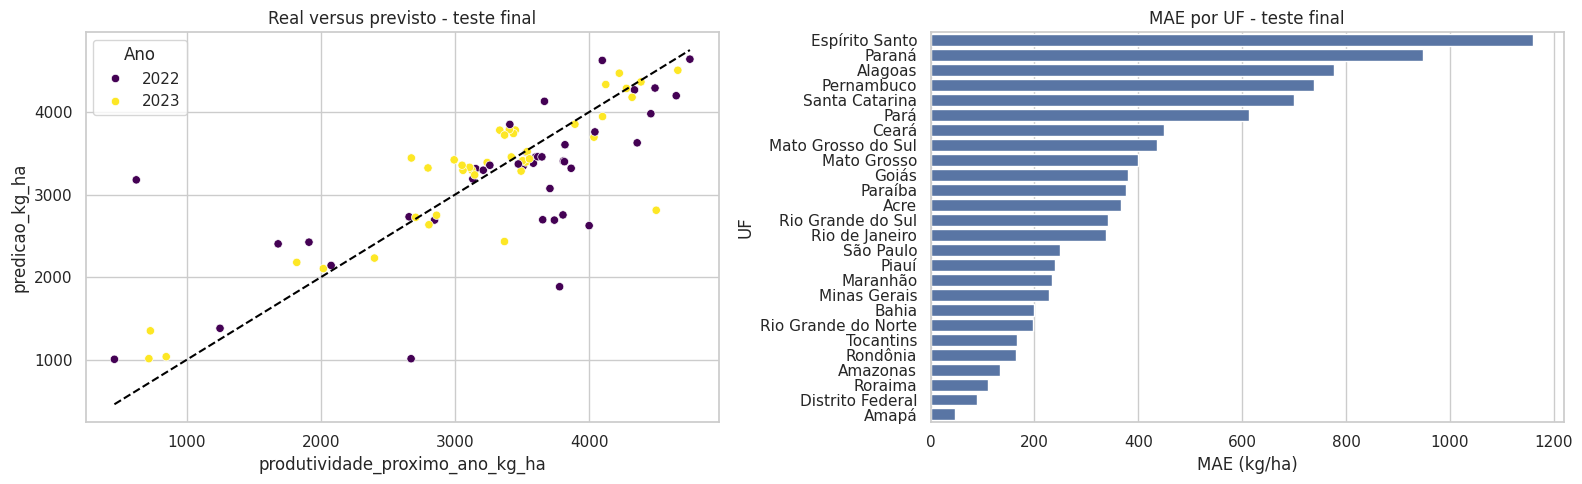

,UF,Ano,produtividade_proximo_ano_kg_ha,predicao_kg_ha,erro_absoluto_kg_ha,erro_assinado_kg_ha
47,Alagoas,2022,625.0,3179.20,2554.20,-2554.20
872,Espírito Santo,2022,3780.0,1885.34,1894.66,1894.66
398,Pará,2023,4500.0,2811.36,1688.64,1688.64
347,Paraná,2022,2673.0,1013.59,1659.41,1659.41
1097,Pernambuco,2022,4000.0,2624.96,1375.04,1375.04
1272,Santa Catarina,2022,3805.0,2754.72,1050.28,1050.28
1022,Paraná,2022,3741.0,2691.83,1049.17,1049.17
972,Mato Grosso do Sul,2022,3654.0,2696.20,957.80,957.80
348,Paraná,2023,3369.0,2432.53,936.47,936.47
1323,São Paulo,2023,2675.0,3444.16,769.16,-769.16


In [ ]:
errors_df = test_df[["UF", "Ano", TARGET]].copy()
errors_df["predicao_kg_ha"] = final_pred
errors_df["erro_absoluto_kg_ha"] = (errors_df[TARGET] - errors_df["predicao_kg_ha"]).abs()
errors_df["erro_assinado_kg_ha"] = errors_df[TARGET] - errors_df["predicao_kg_ha"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(data=errors_df, x=TARGET, y="predicao_kg_ha", hue="Ano", palette="viridis", ax=axes[0])
lim_min = min(errors_df[TARGET].min(), errors_df["predicao_kg_ha"].min())
lim_max = max(errors_df[TARGET].max(), errors_df["predicao_kg_ha"].max())
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], "--", color="black")
axes[0].set_title("Real versus previsto - teste final")

mae_uf = errors_df.groupby("UF", as_index=False)["erro_absoluto_kg_ha"].mean().sort_values("erro_absoluto_kg_ha", ascending=False)
sns.barplot(data=mae_uf, x="erro_absoluto_kg_ha", y="UF", ax=axes[1])
axes[1].set_title("MAE por UF - teste final")
axes[1].set_xlabel("MAE (kg/ha)")

plt.tight_layout()
plt.show()

display(errors_df.sort_values("erro_absoluto_kg_ha", ascending=False).head(10).round(2))

,feature,importance
4,num__produtividade_kg_ha,0.858174
0,num__Ano,0.022987
1,num__area_plantada_ha,0.016620
26,cat__UF_Rio Grande do Norte,0.016456
5,num__valor_producao_mil_reais,0.013774
3,num__producao_t,0.008466
29,cat__UF_Rondônia,0.007413
6,cat__Produto_Algodao herbaceo (em caroco),0.006637
2,num__area_colhida_ha,0.006356
7,cat__Produto_Soja (em grao),0.005945


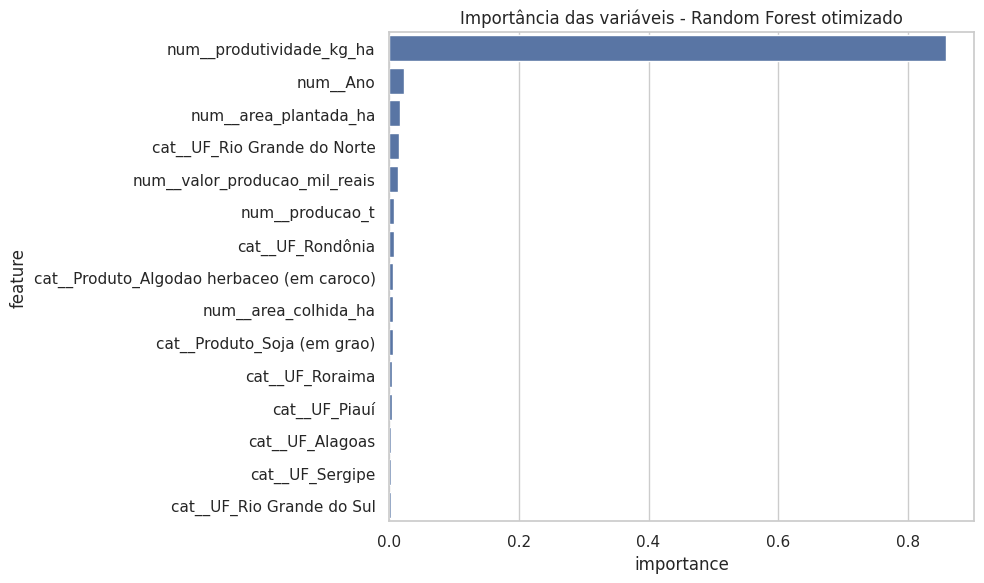

In [ ]:
try:
    preprocessor = final_model.named_steps["preprocess"]
    estimator = final_model.named_steps["model"]
    feature_names = preprocessor.get_feature_names_out()
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": estimator.feature_importances_,
    }).sort_values("importance", ascending=False)
    display(importance_df.head(15))
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df.head(15), x="importance", y="feature")
    plt.title("Importância das variáveis - Random Forest otimizado")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("Não foi possível calcular importâncias:", exc)

## 10.1 Análise de erros, overfitting e limitações

- O modelo apresentou previsões próximas dos valores reais em boa parte dos casos, mas teve erros maiores em alguns estados, principalmente Espírito Santo, Paraná, Alagoas, Pernambuco e Santa Catarina. Esses desvios podem estar relacionados a fatores não incluídos na base, como clima, solo, pragas e condições econômicas.

- Assim, o modelo é adequado no contexto de recorte do MVP para identificar padrões gerais de produtividade, mas não deve ser usado isoladamente para decisões agrícolas ou financeiras.

- A inclusão de variáveis climáticas e dados com maior detalhamento geográfico pode melhorar sua capacidade de generalização.


# 11. Comparação final dos modelos


,Modelo,MAE,RMSE,R2,MAPE_pct,Tempo_treino_s
0,Extra Trees,374.355,587.651,0.629,17.762,3.336
1,Random Forest,379.482,618.289,0.589,18.037,5.001
5,Random Forest otimizado,388.623,597.304,0.617,18.474,150.561
2,Ridge,399.916,557.756,0.666,18.394,0.046
3,Baseline persistente (t -> t+1),412.094,633.431,0.569,17.740,0.000
4,Baseline - média,966.781,1119.596,-0.347,43.839,0.032


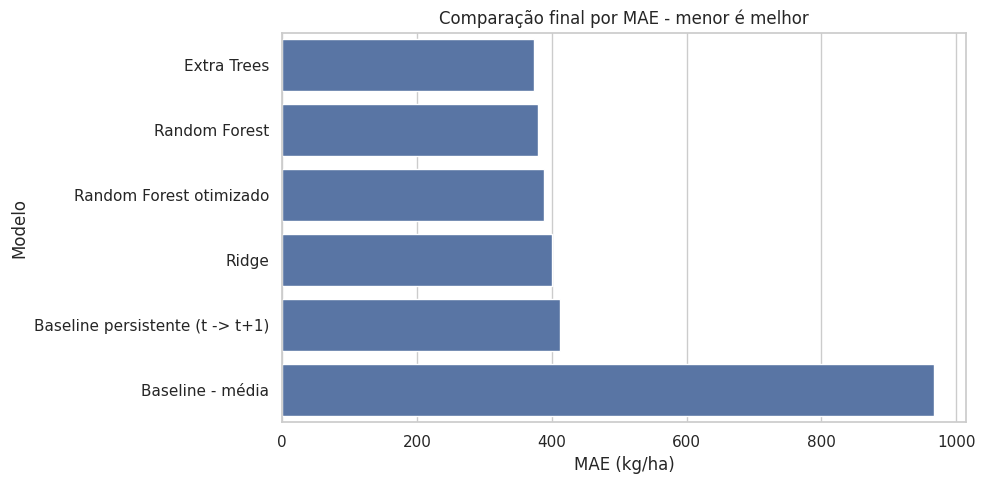

In [ ]:
display(comparison_df.round(3))
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x="MAE", y="Modelo")
plt.title("Comparação final por MAE - menor é melhor")
plt.xlabel("MAE (kg/ha)")
plt.tight_layout()
plt.show()

> O modelo escolhido foi o **Extra Trees**, pois apresentou o menor **MAE** no conjunto de teste final: **374,355 kg/ha** e o mesmo foi definido como métrica principal, por representar diretamente o erro médio de previsão em kg/ha, sendo o critério prioritário para a escolha.

> Além disso, o **Extra Trees** superou os dois baselines e apresentou desempenho competitivo nas demais métricas, com RMSE de 587,651 kg/ha, R² de 0,629 e MAPE de 17,762%. Embora o Ridge tenha obtido o maior R² e menor RMSE, seu **MAE** foi maior (399,916 kg/ha).

> Os resultados obtidos indicam que o Random Forest otimizado não apresentou ganhos de desempenho suficientes para superar o **Extra Trees** na avaliação final. Além disso, o aumento no tempo de treinamento não foi acompanhado por uma melhoria proporcional nas métricas de desempenho. Assim, considerando o equilíbrio entre precisão, capacidade de generalização e eficiência computacional, o modelo **Extra Trees** foi selecionado como a melhor solução.



# 12. Boas práticas e rastreabilidade

- Fonte oficial consultada diretamente por URL pública: PAM/IBGE, tabela 5457.
- O notebook usa a API pública do IBGE como fonte principal e mantém o arquivo `dataset_ibge_soja_algodao.csv` como backup de reprodutibilidade.
- Produtos filtrados: soja (em grão), código 40124; e algodão herbáceo (em caroço), código 40099.
- Seed fixa: 42.
- Unidade de análise: produto + UF + ano.
- Alvo: produtividade da safra seguinte, construída com junção temporal explícita.
- Divisão temporal: treino anterior a 2022; teste a partir de 2022.
- Pré-processamento dentro de `Pipeline`/`ColumnTransformer`.
- Modelos comparados com baseline e otimização realizada sem usar o teste.
- Tempo de treinamento medido.
- A principal limitação do MVP é a ausência de variáveis climáticas, de solo e de dados em maior detalhe geográfico.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| _Fixar SEED = 42_ | _garantir reprodutibilidade dos resultados_ | _permitir que o notebook gere resultados consistentes em novas execuções_ |
| _Soja e algodão herbáceo_ | _ampliar a análise para duas culturas relevantes ao contexto do projeto_ | _aumentar a diversidade dos dados e permitir comparação entre produtos_ |
| _Consultar a API e manter CSV de backup_ | _usar fonte oficial e reduzir risco de falha por indisponibilidade temporária da API_ | _aumentar a reprodutibilidade da entrega_ |
| _Utilizar divisão temporal_ | _objetivo é prever produtividade futura_ | _evitar que dados futuros sejam usados durante o treinamento_ |
| _Criar o alvo do ano seguinte_ | _prever a produtividade de cada produto e UF no período posterior_ | _transformar o problema em regressão temporal supervisionada_ |
| _Usar imputação e One-Hot Encoding no pipeline_ | _há valores ausentes e variáveis categóricas (Produto e UF)_ | _preparar os dados sem vazamento e permitir o uso pelos modelos_ |
| _Padronizar variáveis numéricas_ | _as variáveis possuem escalas muito diferentes_ | _melhorar o funcionamento do modelo Ridge_ |
| _Comparar baselines, Ridge, Random Forest e Extra Trees_ | _avaliar modelos simples e modelos capazes de capturar não linearidades_ | _identificar se modelos mais complexos trazem ganho real_ |
| _Usar MAE como métrica principal_ | _o MAE é interpretável diretamente em kg/ha_ | _escolher o modelo com menor erro médio de produtividade_ |
| _Otimizar Random Forest com validação temporal_ | _buscar hiperparâmetros sem usar o teste final_ | _reduzir risco de overfitting e selecionar configuração mais consistente_ |
| _Escolher Extra Trees como modelo final_ | _apresentou o menor MAE no teste final_ | _minimizar o erro médio de previsão com tempo de treino aceitável_ |


# 13. Conclusão

Este MVP teve como objetivo prever a produtividade de soja e algodão no ano seguinte, por Unidade da Federação, utilizando dados públicos da PAM/IBGE.

Foram comparados baselines, Ridge, Random Forest, Extra Trees e Random Forest otimizado, com divisão temporal para preservar a ordem dos anos.

O modelo escolhido foi o **Extra Trees**, pois apresentou o menor **MAE** no conjunto de teste final: 374,355 kg/ha. Ele também superou os baselines, demonstrando que as variáveis agrícolas, o produto e a UF ajudam a explicar a produtividade futura além de previsões simples baseadas na média ou no valor do ano anterior.

Os resultados mostram que modelos baseados em árvores conseguem capturar relações não lineares entre área plantada, área colhida, produção e produtividade. Ainda assim, alguns estados apresentaram erros maiores, indicando que há fatores relevantes não incluídos na base.

Como limitações, o modelo não considera clima, solo, pragas, preços, teor de óleo, logística ou dados em nível municipal.

**Próximos passo:** recomenda-se incluir variáveis climáticas e maior detalhamento geográfico, testar modelos de boosting e ampliar a análise para outras oleaginosas.

# 14. Salvamento de artefatos (opcional)

In [ ]:
# Opcional: descomente apenas se desejar salvar artefatos na sessão do Colab.
# import joblib
# joblib.dump(final_model, "modelo_produtividade_soja_ibge.pkl")
# comparison_df.to_csv("comparacao_modelos.csv", index=False)
# errors_df.to_csv("erros_teste.csv", index=False)